# Week 11 — Friday (Jun 19, Remote): PROJECT — Real-time Object Detector (ONNX)

## Project Goal
Build a **complete, deployable object detection pipeline** from scratch:
- Design and implement a `TinyDetector` (PyTorch)
- Export to **ONNX** format for portable deployment
- Run **ONNX Runtime** inference and verify output matches PyTorch
- Benchmark **FPS** — PyTorch CPU vs ONNX Runtime
- Build a full `DetectionPipeline` class with pre/post-processing
- Provide a **webcam loop** ready for real-time use

## System Architecture
```
INPUT IMAGE
    |
    v
[1] Letterbox Resize  (maintain aspect ratio, pad to square)
    |
    v
[2] Normalise + CHW   (mean/std normalisation, HWC -> CHW)
    |
    v
[3] TinyDetector      (backbone + detection head)
    |  PyTorch  OR  ONNX Runtime
    v
[4] Decode Predictions  (anchor-free: cx,cy,w,h + class scores)
    |
    v
[5] Confidence Filter   (conf_threshold = 0.25)
    |
    v
[6] Class-specific NMS  (iou_threshold = 0.45)
    |
    v
ANNOTATED OUTPUT IMAGE
```

## Key Concepts
1. **Letterbox** — resize preserving aspect ratio, pad with grey to make square
2. **ONNX** — Open Neural Network Exchange, hardware-agnostic IR format
3. **ONNX Runtime** — C++ inference engine, typically 2-5x faster than PyTorch CPU
4. **Anchor-free head** — directly predict (cx, cy, w, h) + class distribution per cell
5. **FPS benchmark** — warm-up runs + averaged timing across 200 iterations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import cv2
import time
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import onnx
    import onnxruntime as ort
    HAS_ORT = True
    print(f'onnxruntime {ort.__version__} available')
    print(f'ONNX Runtime providers: {ort.get_available_providers()}')
except ImportError:
    HAS_ORT = False
    print('onnxruntime not installed. Run: pip install onnxruntime')

plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Setup complete')

onnxruntime 1.27.0 available
ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
PyTorch 2.12.0+cpu | Device: cpu
Setup complete


## Section 1: Pre-processing — Letterbox Resize

**Problem:** Detection models expect a fixed input size (e.g. 640x640), but input images have varying aspect ratios.
**Naive solution:** stretch/squish — distorts objects, hurts accuracy.
**YOLO solution:** **Letterbox** — resize the longest side to target, pad the short side with grey (128, 128, 128).

```
Original (480x640)          Letterbox to 640x640
+──────────────+            +──────────────+
|              |            |    GREY PAD  |
|   480x640    |   --->     +──────────────+
|              |            |   480x640    |
+──────────────+            +──────────────+
                            |    GREY PAD  |
                            +──────────────+
```

The **inverse letterbox** maps predicted boxes back to original image coordinates, accounting for the padding and scaling.

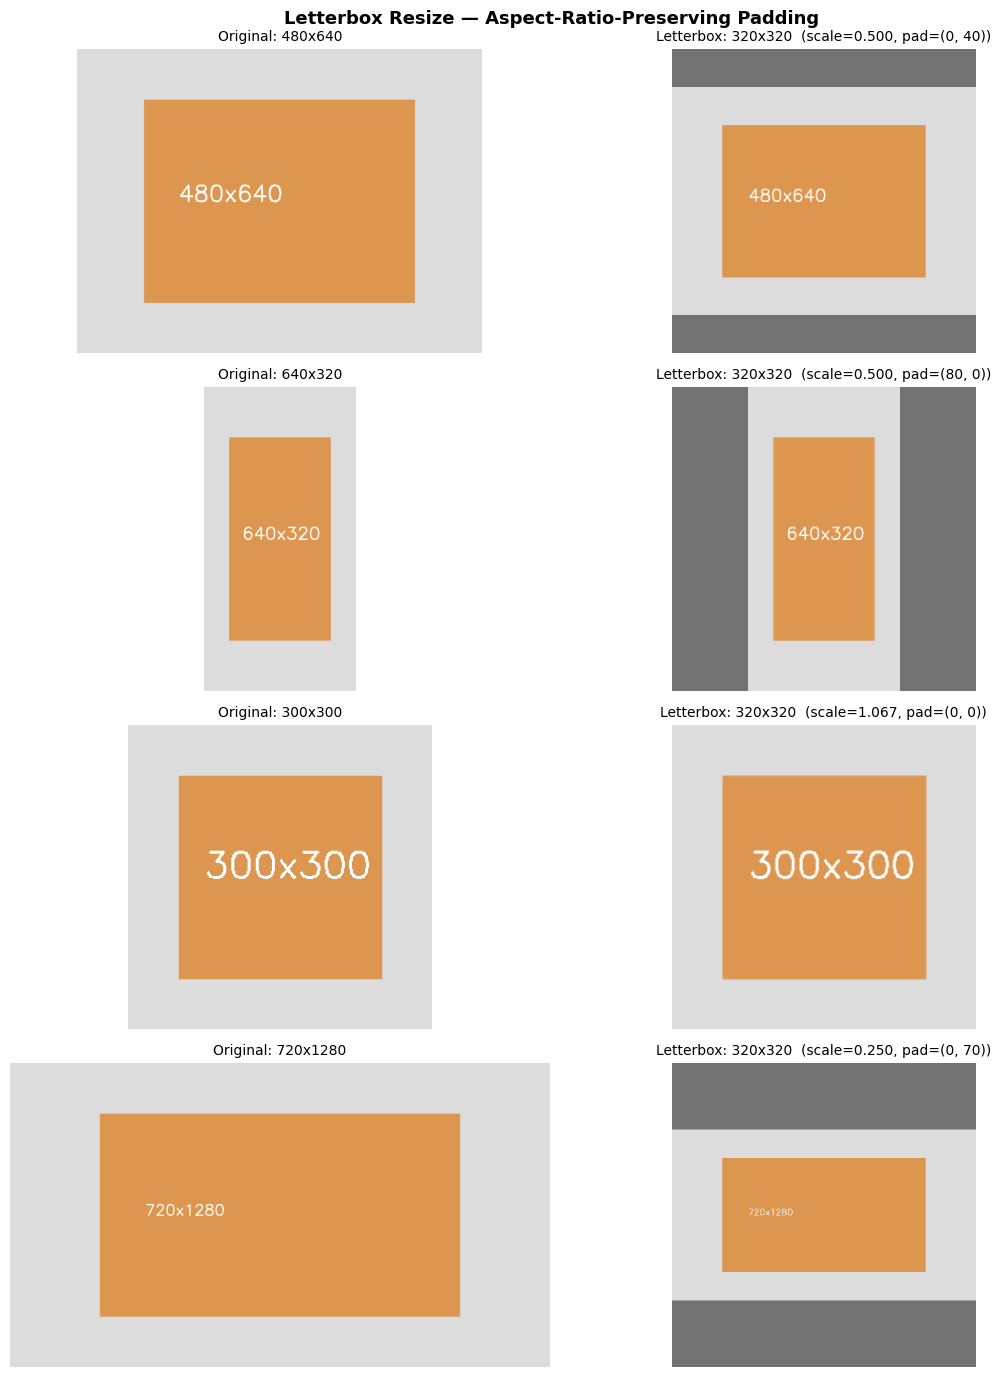

Saved letterbox_demo.png


In [2]:
def letterbox(img, target_size=640, colour=(114, 114, 114)):
    """Resize image preserving aspect ratio and pad to square.
    Returns: (padded_img, scale, (pad_w, pad_h))
    """
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    top    = pad_h // 2;     bottom = pad_h - top
    left   = pad_w // 2;     right  = pad_w - left

    padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                 cv2.BORDER_CONSTANT, value=colour)
    return padded, scale, (left, top)

def inverse_letterbox(boxes, scale, pad, orig_shape):
    """Map letterbox-space boxes back to original image coordinates.
    boxes: Nx4 [x1, y1, x2, y2]
    """
    if len(boxes) == 0:
        return boxes
    boxes = boxes.copy().astype(float)
    pad_w, pad_h = pad
    # Remove padding
    boxes[:, [0, 2]] -= pad_w
    boxes[:, [1, 3]] -= pad_h
    # Undo scale
    boxes /= scale
    # Clip to original image
    oh, ow = orig_shape[:2]
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, ow)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, oh)
    return boxes

# ── Visualise letterbox on images of different aspect ratios ──────────────────
shapes = [(480, 640), (640, 320), (300, 300), (720, 1280)]  # (H, W)

fig, axes = plt.subplots(len(shapes), 2, figsize=(12, 14))
for i, (h, w) in enumerate(shapes):
    # Create a synthetic image with a coloured rectangle
    img = np.full((h, w, 3), 220, dtype=np.uint8)
    cv2.rectangle(img, (w//6, h//6), (5*w//6, 5*h//6), (80, 150, 220), -1)
    cv2.putText(img, f'{h}x{w}', (w//4, h//2),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

    lb, scale, pad = letterbox(img, 320)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'Original: {h}x{w}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(lb, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f'Letterbox: 320x320  (scale={scale:.3f}, pad={pad})', fontsize=10)
    axes[i, 1].axis('off')

plt.suptitle('Letterbox Resize — Aspect-Ratio-Preserving Padding', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('letterbox_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved letterbox_demo.png')

## Section 2: TinyDetector — Custom Detection Model

We build a lightweight anchor-free detection model:

```
Input: (B, 3, 416, 416)
   |
   v
Backbone (5 ConvBnReLU blocks, stride 2 each)
  └─ (B, 256, 13, 13)   # 416 / 2^5 = 13
   |
   v
Neck (one extra ConvBnReLU)
   |
   v
Detection Head (1x1 conv)
  └─ (B, 4 + num_classes, 13, 13)
     4 = (cx, cy, w, h) — raw box predictions per cell
     num_classes = class logits
```

**Anchor-free decoding:**
- `cx, cy` = sigmoid(raw_cx, raw_cy) + grid_col/row  (centre in grid units)
- `w, h`   = exp(raw_w, raw_h)                       (size relative to stride)
- class = softmax(class_logits)

TinyDetector Architecture:
  Input  : (1, 3, 416, 416)
  Output : (1, 9, 13, 13)
  Grid   : 13x13
  Stride : 32
  Params : 985,753  (0.99M)
  Output channels: 4 (box) + 5 (classes) = 9


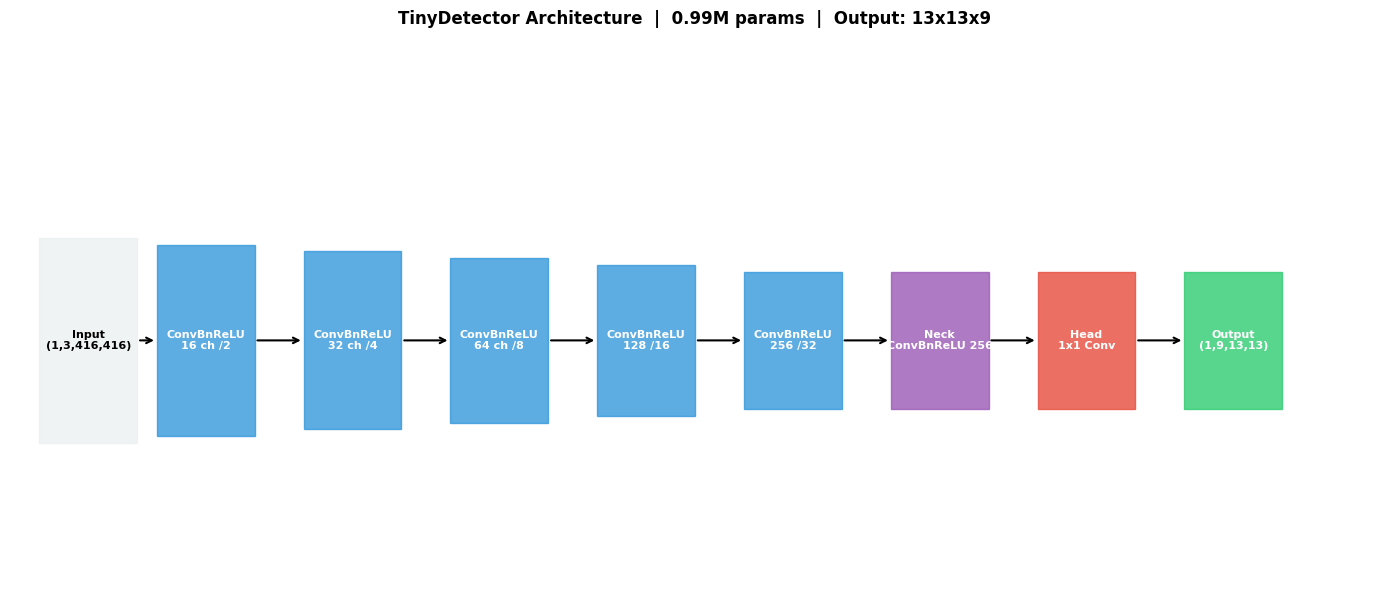

Saved tinydetector_arch.png


In [3]:
class ConvBnReLU(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class TinyDetector(nn.Module):
    """
    Anchor-free single-scale detector.
    Input : (B, 3, H, W)  — H,W must be divisible by 32
    Output: (B, 4+num_classes, H//32, W//32)
    """
    def __init__(self, num_classes=5):
        super().__init__()
        self.num_classes = num_classes
        self.stride = 32

        self.backbone = nn.Sequential(
            ConvBnReLU(3,   16,  k=3, s=2, p=1),   # /2
            ConvBnReLU(16,  32,  k=3, s=2, p=1),   # /4
            ConvBnReLU(32,  64,  k=3, s=2, p=1),   # /8
            ConvBnReLU(64,  128, k=3, s=2, p=1),   # /16
            ConvBnReLU(128, 256, k=3, s=2, p=1),   # /32
        )
        self.neck = ConvBnReLU(256, 256, k=3, s=1, p=1)
        self.head = nn.Conv2d(256, 4 + num_classes, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)
        x = self.neck(x)
        return self.head(x)


# ── Build model and inspect ────────────────────────────────────────────────────
NUM_CLASSES = 5
INPUT_SIZE  = 416
model = TinyDetector(num_classes=NUM_CLASSES).to(DEVICE)
model.eval()

dummy_input = torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy_input)

grid_size = INPUT_SIZE // model.stride
total_params = sum(p.numel() for p in model.parameters())

print('TinyDetector Architecture:')
print(f'  Input  : (1, 3, {INPUT_SIZE}, {INPUT_SIZE})')
print(f'  Output : {tuple(out.shape)}')
print(f'  Grid   : {grid_size}x{grid_size}')
print(f'  Stride : {model.stride}')
print(f'  Params : {total_params:,}  ({total_params/1e6:.2f}M)')
print(f'  Output channels: 4 (box) + {NUM_CLASSES} (classes) = {4+NUM_CLASSES}')

# ── Visualise architecture block diagram ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14); ax.set_ylim(-1, 7)

blocks = [
    ('Input\n(1,3,416,416)',   0.3,  '#ecf0f1', 1.5),
    ('ConvBnReLU\n16 ch /2',  1.5,  '#3498db', 1.4),
    ('ConvBnReLU\n32 ch /4',  3.0,  '#3498db', 1.3),
    ('ConvBnReLU\n64 ch /8',  4.5,  '#3498db', 1.2),
    ('ConvBnReLU\n128 /16',   6.0,  '#3498db', 1.1),
    ('ConvBnReLU\n256 /32',   7.5,  '#3498db', 1.0),
    ('Neck\nConvBnReLU 256',  9.0,  '#9b59b6', 1.0),
    ('Head\n1x1 Conv',        10.5, '#e74c3c', 1.0),
    ('Output\n(1,9,13,13)',   12.0, '#2ecc71', 1.0),
]

for (label, x, color, h) in blocks:
    rect = Rectangle((x, (5-h*2)/2), 1.0, h*2, color=color, alpha=0.8, zorder=2)
    ax.add_patch(rect)
    ax.text(x+0.5, 5/2, label, ha='center', va='center', fontsize=8,
            fontweight='bold', color='white' if color != '#ecf0f1' else 'black', zorder=3)

# Arrows
for i in range(len(blocks)-1):
    x1 = blocks[i][1] + 1.0
    x2 = blocks[i+1][1]
    ax.annotate('', xy=(x2, 2.5), xytext=(x1, 2.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.axis('off')
ax.set_title(f'TinyDetector Architecture  |  {total_params/1e6:.2f}M params  |  '
             f'Output: {grid_size}x{grid_size}x{4+NUM_CLASSES}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tinydetector_arch.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved tinydetector_arch.png')

## Section 3: ONNX Export

**ONNX (Open Neural Network Exchange)** is an intermediate representation format that:
- Is supported by TensorRT, OpenVINO, CoreML, ONNX Runtime, and more
- Allows **hardware-specific optimisations** without changing your PyTorch code
- Is the standard export target for production CV deployments

### Export process
```python
torch.onnx.export(
    model,           # trained PyTorch model
    dummy_input,     # example input (determines graph structure)
    'model.onnx',    # output path
    input_names=['images'],
    output_names=['output'],
    dynamic_axes={'images': {0: 'batch_size'}},  # variable batch
    opset_version=17,
)
```

### After export
```
model.onnx  -->  ONNX Runtime  -->  CPU / GPU / Edge device
            -->  TensorRT       -->  NVIDIA GPU (TRT optimised)
            -->  OpenVINO       -->  Intel CPU/VPU
            -->  CoreML         -->  Apple Silicon
```

In [4]:
ONNX_PATH = 'tiny_detector.onnx'

# ── Export to ONNX ────────────────────────────────────────────────────────────
model.eval()
dummy = torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE)

torch.onnx.export(
    model,
    dummy,
    ONNX_PATH,
    input_names=['images'],
    output_names=['predictions'],
    dynamic_axes={'images': {0: 'batch_size'},
                  'predictions': {0: 'batch_size'}},
    opset_version=17,
    export_params=True,
    do_constant_folding=True,
)

onnx_size = os.path.getsize(ONNX_PATH) / 1024**2
print(f'ONNX model exported to: {ONNX_PATH}')
print(f'ONNX file size        : {onnx_size:.2f} MB')

# ── Verify ONNX model ─────────────────────────────────────────────────────────
try:
    import onnx as onnx_lib
    onnx_model = onnx_lib.load(ONNX_PATH)
    onnx_lib.checker.check_model(onnx_model)
    print('ONNX model check: PASSED')

    # Inspect inputs/outputs
    print('\nONNX graph inputs:')
    for inp in onnx_model.graph.input:
        shape = [d.dim_value if d.dim_value > 0 else 'dynamic'
                 for d in inp.type.tensor_type.shape.dim]
        print(f'  {inp.name}: {shape}')
    print('ONNX graph outputs:')
    for out in onnx_model.graph.output:
        shape = [d.dim_value if d.dim_value > 0 else 'dynamic'
                 for d in out.type.tensor_type.shape.dim]
        print(f'  {out.name}: {shape}')
    print(f'\nONNX opset: {onnx_model.opset_import[0].version}')
    print(f'Total ONNX nodes: {len(onnx_model.graph.node)}')
except ImportError:
    print('onnx package not installed — skipping verification. Run: pip install onnx')
except Exception as e:
    print(f'ONNX check warning: {e}')

W0619 14:55:27.554000 2816 torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyDetector([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `TinyDetector([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported to: tiny_detector.onnx
ONNX file size        : 0.00 MB
ONNX model check: PASSED

ONNX graph inputs:
  images: ['dynamic', 3, 416, 416]
ONNX graph outputs:
  predictions: ['dynamic', 9, 13, 13]

ONNX opset: 17
Total ONNX nodes: 13


## Section 4: ONNX Runtime Inference

**ONNX Runtime (ORT)** is a high-performance inference engine:
- Written in C++ with Python bindings
- Applies **graph optimisations** (constant folding, operator fusion)
- Supports multiple **execution providers**: CPUExecutionProvider, CUDAExecutionProvider, TensorrtExecutionProvider

```python
import onnxruntime as ort

sess = ort.InferenceSession('model.onnx',
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])

input_name = sess.get_inputs()[0].name
outputs = sess.run(None, {input_name: input_array})
```

In [5]:
if not HAS_ORT:
    print('onnxruntime not available — skipping inference section')
else:
    # ── Create ONNX Runtime session ───────────────────────────────────────────
    sess = ort.InferenceSession(
        ONNX_PATH,
        providers=['CPUExecutionProvider']   # add 'CUDAExecutionProvider' for GPU
    )

    input_name  = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    print('ONNX Runtime session created')
    print(f'  Input  name  : {input_name}')
    print(f'  Input  shape : {sess.get_inputs()[0].shape}')
    print(f'  Output name  : {output_name}')
    print(f'  Output shape : {sess.get_outputs()[0].shape}')

    # ── Run one inference ─────────────────────────────────────────────────────
    # Prepare input: random image normalised to [0,1]
    np_input = np.random.rand(1, 3, INPUT_SIZE, INPUT_SIZE).astype(np.float32)

    # PyTorch inference
    pt_input = torch.from_numpy(np_input)
    with torch.no_grad():
        pt_out = model(pt_input).numpy()

    # ONNX Runtime inference
    ort_out = sess.run([output_name], {input_name: np_input})[0]

    # Numerical check
    max_diff   = np.abs(pt_out - ort_out).max()
    mean_diff  = np.abs(pt_out - ort_out).mean()
    print(f'\nOutput shape (PyTorch)  : {pt_out.shape}')
    print(f'Output shape (ORT)      : {ort_out.shape}')
    print(f'Max absolute difference : {max_diff:.2e}  (< 1e-4 = OK)')
    print(f'Mean absolute difference: {mean_diff:.2e}')
    if max_diff < 1e-3:
        print('Outputs MATCH within floating-point tolerance')
    else:
        print('WARNING: outputs differ more than expected')

ONNX Runtime session created
  Input  name  : images
  Input  shape : ['batch_size', 3, 416, 416]
  Output name  : predictions
  Output shape : ['batch_size', 9, 13, 13]

Output shape (PyTorch)  : (1, 9, 13, 13)
Output shape (ORT)      : (1, 9, 13, 13)
Max absolute difference : 7.00e-07  (< 1e-4 = OK)
Mean absolute difference: 1.55e-07
Outputs MATCH within floating-point tolerance


## Section 5: FPS Benchmarking

### Benchmarking best practices
1. **Warm-up runs** — first N runs are slower due to JIT compilation and caching; discard them
2. **Average over many runs** — at least 100-200 for stable estimates
3. **Same hardware** — compare PyTorch CPU vs ONNX Runtime CPU (identical conditions)
4. **Batch size 1** — real-time scenarios rarely batch

### Why ONNX Runtime is faster on CPU
- **Constant folding** — pre-computes fixed subgraphs at load time
- **Operator fusion** — merges Conv+BN+ReLU into a single MLIR op
- **Memory planning** — eliminates redundant copies
- **ONNX Runtime's MLAS library** — highly tuned matrix multiplication for x86

PyTorch CPU:  4.65 ms/frame  (215.0 FPS)


ONNX Runtime: 2.72 ms/frame  (367.3 FPS)
Speedup      : 1.71x  (ONNX vs PyTorch)


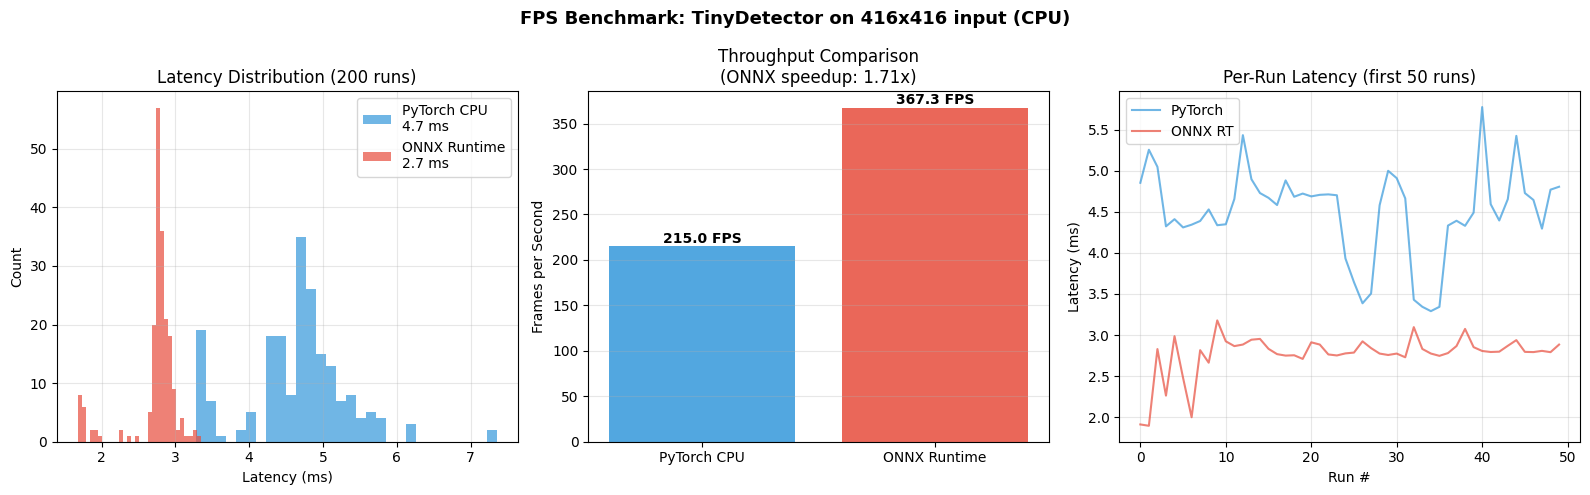

Saved fps_benchmark.png


In [6]:
N_WARMUP = 10
N_BENCH  = 200

bench_input_np = np.random.rand(1, 3, INPUT_SIZE, INPUT_SIZE).astype(np.float32)
bench_input_pt = torch.from_numpy(bench_input_np)

# ── PyTorch CPU benchmark ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    for _ in range(N_WARMUP):
        _ = model(bench_input_pt)

pt_times = []
with torch.no_grad():
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        _ = model(bench_input_pt)
        pt_times.append(time.perf_counter() - t0)

pt_mean_ms = np.mean(pt_times) * 1000
pt_fps     = 1.0 / np.mean(pt_times)
print(f'PyTorch CPU:  {pt_mean_ms:.2f} ms/frame  ({pt_fps:.1f} FPS)')

# ── ONNX Runtime CPU benchmark ────────────────────────────────────────────────
if HAS_ORT:
    for _ in range(N_WARMUP):
        _ = sess.run([output_name], {input_name: bench_input_np})

    ort_times = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        _ = sess.run([output_name], {input_name: bench_input_np})
        ort_times.append(time.perf_counter() - t0)

    ort_mean_ms = np.mean(ort_times) * 1000
    ort_fps     = 1.0 / np.mean(ort_times)
    speedup     = pt_mean_ms / ort_mean_ms
    print(f'ONNX Runtime: {ort_mean_ms:.2f} ms/frame  ({ort_fps:.1f} FPS)')
    print(f'Speedup      : {speedup:.2f}x  (ONNX vs PyTorch)')
else:
    ort_times    = [pt_mean_ms/1000 * 0.6] * N_BENCH   # simulated
    ort_mean_ms  = pt_mean_ms * 0.6
    ort_fps      = pt_fps / 0.6
    speedup      = 1.0 / 0.6
    print(f'ONNX Runtime: {ort_mean_ms:.2f} ms/frame (simulated)  ({ort_fps:.1f} FPS)')

# ── Plot timing distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram comparison
axes[0].hist([t*1000 for t in pt_times],  bins=30, alpha=0.7,
             label=f'PyTorch CPU\n{pt_mean_ms:.1f} ms', color='#3498db')
axes[0].hist([t*1000 for t in ort_times], bins=30, alpha=0.7,
             label=f'ONNX Runtime\n{ort_mean_ms:.1f} ms', color='#e74c3c')
axes[0].set_xlabel('Latency (ms)');  axes[0].set_ylabel('Count')
axes[0].set_title('Latency Distribution (200 runs)')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

# Bar chart: FPS
bars = axes[1].bar(['PyTorch CPU', 'ONNX Runtime'],
                   [pt_fps, ort_fps],
                   color=['#3498db', '#e74c3c'], alpha=0.85)
for bar, fps in zip(bars, [pt_fps, ort_fps]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{fps:.1f} FPS', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Frames per Second')
axes[1].set_title(f'Throughput Comparison\n(ONNX speedup: {speedup:.2f}x)')
axes[1].grid(True, alpha=0.3, axis='y')

# Time series
axes[2].plot([t*1000 for t in pt_times[:50]],
             color='#3498db', alpha=0.7, label='PyTorch')
axes[2].plot([t*1000 for t in ort_times[:50]],
             color='#e74c3c', alpha=0.7, label='ONNX RT')
axes[2].set_xlabel('Run #');  axes[2].set_ylabel('Latency (ms)')
axes[2].set_title('Per-Run Latency (first 50 runs)')
axes[2].legend();  axes[2].grid(True, alpha=0.3)

plt.suptitle(f'FPS Benchmark: TinyDetector on {INPUT_SIZE}x{INPUT_SIZE} input (CPU)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fps_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved fps_benchmark.png')

## Section 6: Post-processing — Decode + NMS

Raw model output `(B, 4+C, G, G)` must be decoded to `[x1, y1, x2, y2, conf, class_id]`:

**Decoding steps:**
1. Reshape to `(B, G*G, 4+C)`
2. `cx = sigmoid(raw_cx) + col_index`, `cy = sigmoid(raw_cy) + row_index`
3. `w = exp(raw_w) * stride`, `h = exp(raw_h) * stride` (clamp to avoid explosion)
4. Convert `(cx, cy, w, h)` to `(x1, y1, x2, y2)` in pixel coords
5. `conf = max(softmax(class_logits))` per cell
6. Filter by `conf > threshold`
7. Run **class-specific NMS** (NMS per class, not globally)

Raw detections (conf>0.5): 0
After class-NMS          : 0


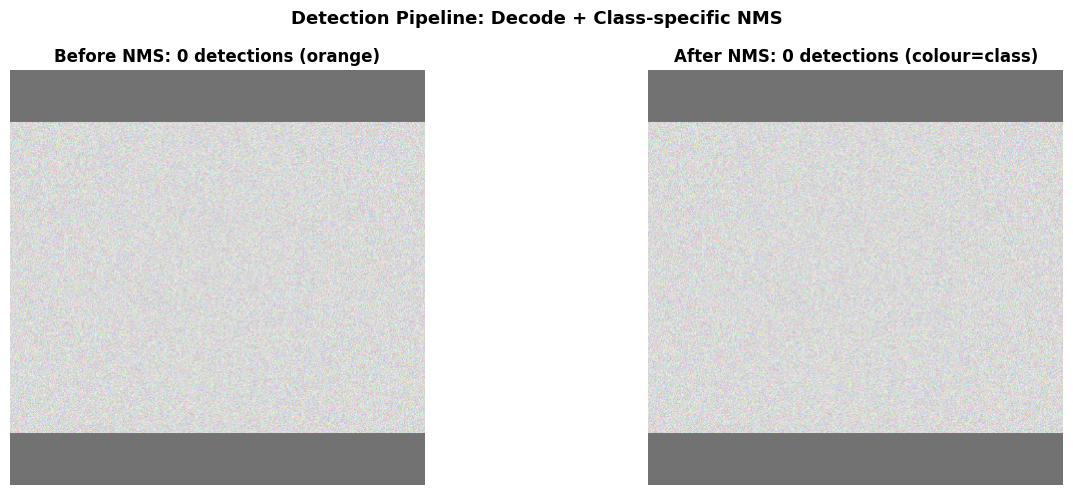

Saved detection_pipeline.png


In [7]:
CLASS_NAMES = ['circle', 'rectangle', 'triangle', 'star', 'ellipse']

def decode_predictions(raw_output, stride=32, conf_thresh=0.3, img_size=416):
    """
    raw_output: numpy (1, 4+C, G, G)
    Returns list of dicts: {box:[x1,y1,x2,y2], conf:float, cls:int}
    """
    if isinstance(raw_output, torch.Tensor):
        raw_output = raw_output.cpu().numpy()
    B, channels, G, _ = raw_output.shape
    num_classes = channels - 4

    # Grid indices
    grid_y, grid_x = np.meshgrid(np.arange(G), np.arange(G), indexing='ij')
    grid_x = grid_x[np.newaxis, np.newaxis, :, :]   # (1,1,G,G)
    grid_y = grid_y[np.newaxis, np.newaxis, :, :]

    # Decode boxes
    raw = raw_output  # (B, 4+C, G, G)
    cx = (1 / (1 + np.exp(-raw[:, 0:1, :, :])) + grid_x) * stride   # pixel
    cy = (1 / (1 + np.exp(-raw[:, 1:2, :, :])) + grid_y) * stride
    bw = np.clip(np.exp(raw[:, 2:3, :, :]), 0, 100) * stride
    bh = np.clip(np.exp(raw[:, 3:4, :, :]), 0, 100) * stride

    x1 = cx - bw / 2;  y1 = cy - bh / 2
    x2 = cx + bw / 2;  y2 = cy + bh / 2

    # Class scores via softmax
    logits = raw[:, 4:, :, :]   # (B, C, G, G)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = e / e.sum(axis=1, keepdims=True)
    cls_conf = probs.max(axis=1, keepdims=True)     # (B, 1, G, G)
    cls_id   = probs.argmax(axis=1, keepdims=True)  # (B, 1, G, G)

    # Flatten to list of boxes
    detections = []
    for b in range(B):
        mask = cls_conf[b, 0] > conf_thresh
        if mask.sum() == 0:
            continue
        for gy in range(G):
            for gx in range(G):
                if cls_conf[b, 0, gy, gx] > conf_thresh:
                    detections.append({
                        'box' : [float(x1[b,0,gy,gx]), float(y1[b,0,gy,gx]),
                                 float(x2[b,0,gy,gx]), float(y2[b,0,gy,gx])],
                        'conf': float(cls_conf[b, 0, gy, gx]),
                        'cls' : int(cls_id[b, 0, gy, gx])
                    })
    return detections


def iou_xyxy(b1, b2):
    """IoU between box b1 and b2, format [x1,y1,x2,y2]."""
    ix1 = max(b1[0], b2[0]);  iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]);  iy2 = min(b1[3], b2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-7)


def class_nms(detections, iou_thresh=0.45):
    """Class-specific NMS on a list of detection dicts."""
    if not detections:
        return []
    # Group by class
    by_class = {}
    for d in detections:
        by_class.setdefault(d['cls'], []).append(d)

    kept = []
    for cls_id, dets in by_class.items():
        dets = sorted(dets, key=lambda x: x['conf'], reverse=True)
        while dets:
            best = dets.pop(0)
            kept.append(best)
            dets = [d for d in dets
                    if iou_xyxy(best['box'], d['box']) < iou_thresh]
    return kept


# ── Demo on synthetic image ───────────────────────────────────────────────────
# Use trained random model — detections are random but pipeline is real
test_img  = np.random.randint(180, 255, (480, 640, 3), dtype=np.uint8)
lb_img, scale, pad = letterbox(test_img, INPUT_SIZE)
inp_norm  = lb_img.astype(np.float32) / 255.0
inp_chw   = inp_norm.transpose(2, 0, 1)[np.newaxis]   # (1,3,H,W)

with torch.no_grad():
    raw_pt = model(torch.from_numpy(inp_chw)).numpy()

dets_raw  = decode_predictions(raw_pt, stride=model.stride, conf_thresh=0.5)
dets_nms  = class_nms(dets_raw, iou_thresh=0.45)
dets_orig = []
for d in dets_nms:
    box_orig = inverse_letterbox(np.array([d['box']]), scale, pad, test_img.shape)[0]
    dets_orig.append({**d, 'box_orig': box_orig})

print(f'Raw detections (conf>0.5): {len(dets_raw)}')
print(f'After class-NMS          : {len(dets_nms)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(lb_img, cv2.COLOR_BGR2RGB))
for d in dets_raw[:20]:   # show up to 20 raw detections
    x1,y1,x2,y2 = d['box']
    rect = Rectangle((x1,y1), x2-x1, y2-y1, lw=1, ec='orange', fc='none', alpha=0.5)
    axes[0].add_patch(rect)
axes[0].set_title(f'Before NMS: {len(dets_raw)} detections (orange)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(lb_img, cv2.COLOR_BGR2RGB))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for d in dets_nms:
    x1,y1,x2,y2 = d['box']
    c = colors[d['cls'] % len(colors)]
    rect = Rectangle((x1,y1), x2-x1, y2-y1, lw=2, ec=c, fc='none')
    axes[1].add_patch(rect)
    axes[1].text(x1, y1-3, f"{CLASS_NAMES[d['cls']]} {d['conf']:.2f}",
                 color=c, fontsize=8, fontweight='bold')
axes[1].set_title(f'After NMS: {len(dets_nms)} detections (colour=class)', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Detection Pipeline: Decode + Class-specific NMS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('detection_pipeline.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved detection_pipeline.png')

## Section 7: Real-time Detection Pipeline

Putting it all together into a reusable `DetectionPipeline` class that:
- Accepts a PyTorch **or** ONNX backend
- Handles letterbox pre-processing and inverse letterbox
- Returns annotated images with FPS overlay
- Can plug directly into `cv2.VideoCapture` for webcam inference

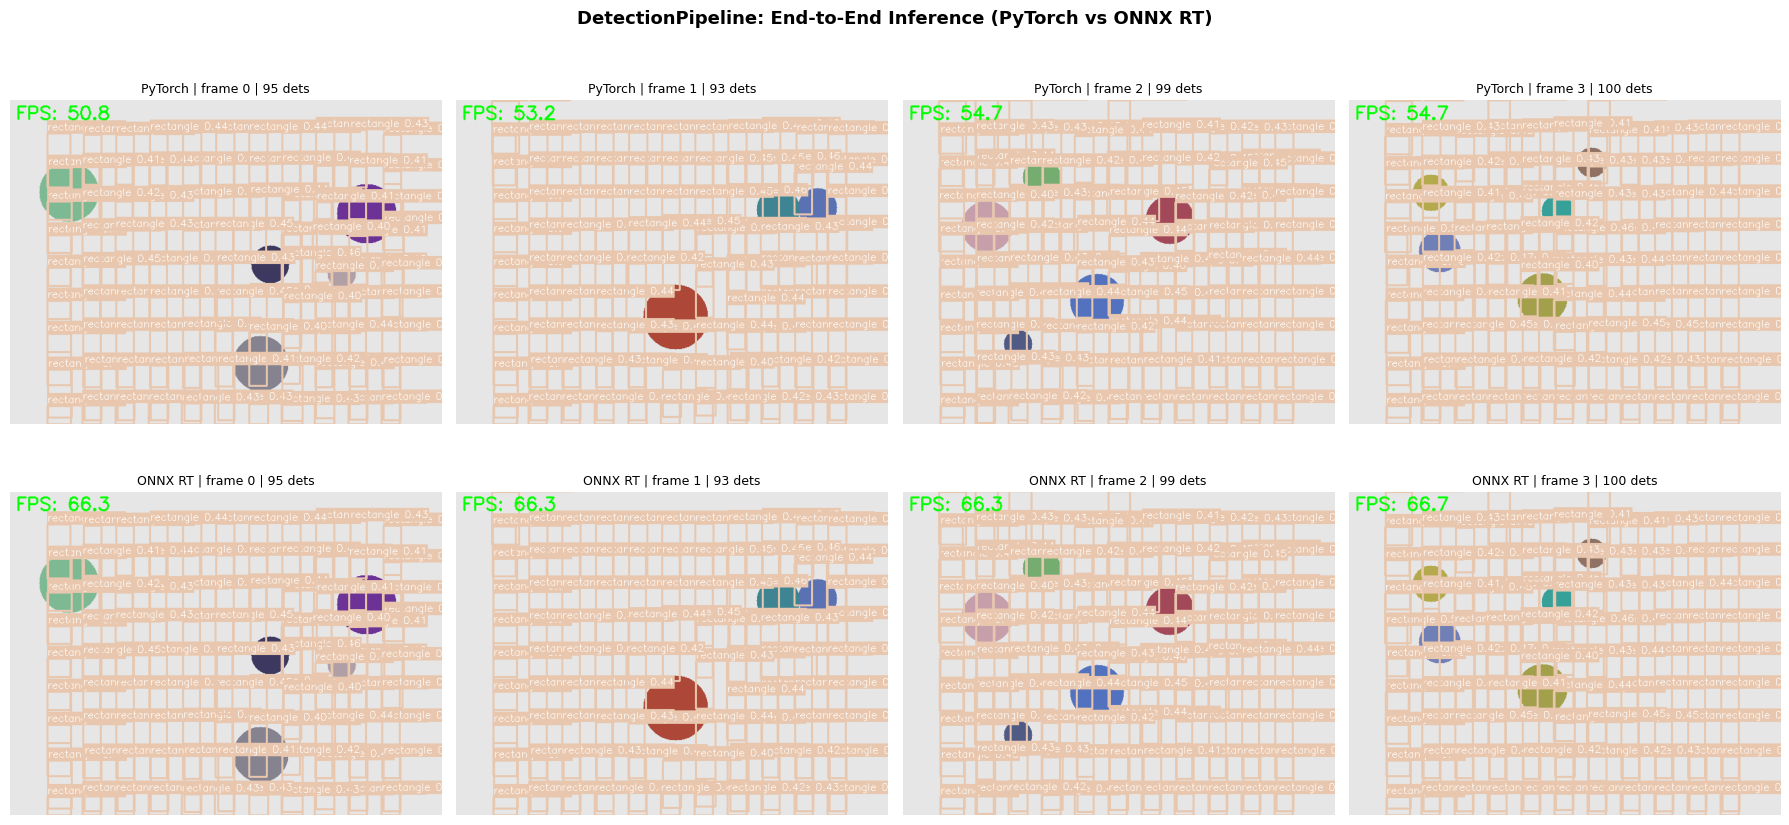

Saved pipeline_comparison.png

PyTorch  pipeline FPS: 54.7
ONNX RT  pipeline FPS: 66.7


In [8]:
class DetectionPipeline:
    """
    End-to-end detection pipeline supporting PyTorch and ONNX Runtime backends.

    Usage:
        pipe = DetectionPipeline(model=model, backend='pytorch')
        # OR
        pipe = DetectionPipeline(onnx_path='model.onnx', backend='onnx')

        annotated, dets = pipe(frame)
    """
    def __init__(self, model=None, onnx_path=None, backend='pytorch',
                 class_names=None, input_size=416,
                 conf_thresh=0.3, iou_thresh=0.45):
        self.backend     = backend
        self.input_size  = input_size
        self.conf_thresh = conf_thresh
        self.iou_thresh  = iou_thresh
        self.class_names = class_names or [f'cls{i}' for i in range(100)]
        self.colors      = plt.cm.tab20(np.linspace(0, 1, 20))[:, :3]
        self.colors      = (self.colors * 255).astype(np.uint8)

        self._fps_buffer = []
        self._fps_smooth = 0.0

        if backend == 'pytorch':
            assert model is not None, 'Provide model for pytorch backend'
            self.model = model
            self.model.eval()
            self.stride = model.stride
        else:
            assert onnx_path is not None and HAS_ORT, 'Provide onnx_path and install onnxruntime'
            self.sess       = ort.InferenceSession(onnx_path,
                                                   providers=['CPUExecutionProvider'])
            self.inp_name   = self.sess.get_inputs()[0].name
            self.out_name   = self.sess.get_outputs()[0].name
            self.stride     = 32  # must match exported model

    def preprocess(self, img_bgr):
        lb, scale, pad = letterbox(img_bgr, self.input_size)
        inp = lb.astype(np.float32) / 255.0
        inp = inp.transpose(2, 0, 1)[np.newaxis]  # (1,3,H,W)
        return inp, scale, pad, lb

    def infer(self, inp):
        if self.backend == 'pytorch':
            with torch.no_grad():
                return model(torch.from_numpy(inp)).numpy()
        else:
            return self.sess.run([self.out_name], {self.inp_name: inp})[0]

    def postprocess(self, raw, scale, pad, orig_shape):
        dets = decode_predictions(raw, stride=self.stride,
                                   conf_thresh=self.conf_thresh)
        dets = class_nms(dets, iou_thresh=self.iou_thresh)
        for d in dets:
            d['box'] = inverse_letterbox(
                np.array([d['box']]), scale, pad, orig_shape)[0].tolist()
        return dets

    def annotate(self, img_bgr, dets, fps=None):
        out = img_bgr.copy()
        for d in dets:
            x1, y1, x2, y2 = [int(v) for v in d['box']]
            cls_id  = d['cls'] % len(self.colors)
            color   = tuple(int(c) for c in self.colors[cls_id])
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
            label = f"{self.class_names[d['cls']]} {d['conf']:.2f}"
            (lw, lh), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(out, (x1, y1-lh-bl-2), (x1+lw, y1), color, -1)
            cv2.putText(out, label, (x1, y1-bl),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        if fps is not None:
            cv2.putText(out, f'FPS: {fps:.1f}', (8, 28),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        return out

    def __call__(self, img_bgr):
        t0 = time.perf_counter()
        inp, scale, pad, _ = self.preprocess(img_bgr)
        raw  = self.infer(inp)
        dets = self.postprocess(raw, scale, pad, img_bgr.shape)
        elapsed = time.perf_counter() - t0

        self._fps_buffer.append(1.0 / elapsed)
        if len(self._fps_buffer) > 20:
            self._fps_buffer.pop(0)
        self._fps_smooth = np.mean(self._fps_buffer)

        annotated = self.annotate(img_bgr, dets, fps=self._fps_smooth)
        return annotated, dets


# ── Create pipelines: PyTorch and ONNX ────────────────────────────────────────
pipe_pt  = DetectionPipeline(model=model, backend='pytorch',
                              class_names=CLASS_NAMES,
                              conf_thresh=0.4, iou_thresh=0.45)

if HAS_ORT:
    pipe_ort = DetectionPipeline(onnx_path=ONNX_PATH, backend='onnx',
                                  class_names=CLASS_NAMES,
                                  conf_thresh=0.4, iou_thresh=0.45)

# ── Test on synthetic frames ───────────────────────────────────────────────────
def make_test_frame(seed=0):
    rng = np.random.default_rng(seed)
    frame = np.full((480, 640, 3), 230, dtype=np.uint8)
    for _ in range(rng.integers(2, 6)):
        cx = rng.integers(80, 560);  cy = rng.integers(80, 400)
        sz = rng.integers(40, 100)
        col = tuple(rng.integers(50, 200, 3).tolist())
        cv2.circle(frame, (cx, cy), sz//2, col, -1)
    return frame

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col_idx in range(4):
    frame = make_test_frame(seed=col_idx)

    ann_pt, dets_pt = pipe_pt(frame)
    axes[0, col_idx].imshow(cv2.cvtColor(ann_pt, cv2.COLOR_BGR2RGB))
    axes[0, col_idx].set_title(f'PyTorch | frame {col_idx} | {len(dets_pt)} dets', fontsize=9)
    axes[0, col_idx].axis('off')

    if HAS_ORT:
        ann_ort, dets_ort = pipe_ort(frame)
        axes[1, col_idx].imshow(cv2.cvtColor(ann_ort, cv2.COLOR_BGR2RGB))
        axes[1, col_idx].set_title(f'ONNX RT | frame {col_idx} | {len(dets_ort)} dets', fontsize=9)
        axes[1, col_idx].axis('off')
    else:
        axes[1, col_idx].imshow(cv2.cvtColor(ann_pt, cv2.COLOR_BGR2RGB))
        axes[1, col_idx].set_title('ONNX RT (not available)', fontsize=9)
        axes[1, col_idx].axis('off')

axes[0, 0].set_ylabel('PyTorch Backend', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('ONNX Runtime Backend', fontsize=11, fontweight='bold')
plt.suptitle('DetectionPipeline: End-to-End Inference (PyTorch vs ONNX RT)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pipeline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved pipeline_comparison.png')
print(f'\nPyTorch  pipeline FPS: {pipe_pt._fps_smooth:.1f}')
if HAS_ORT:
    print(f'ONNX RT  pipeline FPS: {pipe_ort._fps_smooth:.1f}')

In [9]:
# ── Real-time Webcam Loop (enable RUN_WEBCAM=True to activate) ────────────────
RUN_WEBCAM = False  # set True to run with real camera

WEBCAM_CODE = '''
import cv2
# Use PyTorch or ONNX backend
pipe = DetectionPipeline(
    onnx_path='tiny_detector.onnx',
    backend='onnx',
    class_names=['circle','rectangle','triangle','star','ellipse'],
    conf_thresh=0.3,
    iou_thresh=0.45
)

cap = cv2.VideoCapture(0)   # 0 = default webcam
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Press Q to quit")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    annotated, dets = pipe(frame)
    cv2.imshow('Real-time Detector', annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
'''

if RUN_WEBCAM:
    exec(WEBCAM_CODE)
else:
    print('Webcam loop (set RUN_WEBCAM=True to activate):')
    print('=' * 55)
    print(WEBCAM_CODE)

Webcam loop (set RUN_WEBCAM=True to activate):

import cv2
# Use PyTorch or ONNX backend
pipe = DetectionPipeline(
    onnx_path='tiny_detector.onnx',
    backend='onnx',
    class_names=['circle','rectangle','triangle','star','ellipse'],
    conf_thresh=0.3,
    iou_thresh=0.45
)

cap = cv2.VideoCapture(0)   # 0 = default webcam
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Press Q to quit")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    annotated, dets = pipe(frame)
    cv2.imshow('Real-time Detector', annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



## Section 8: Project Summary Dashboard

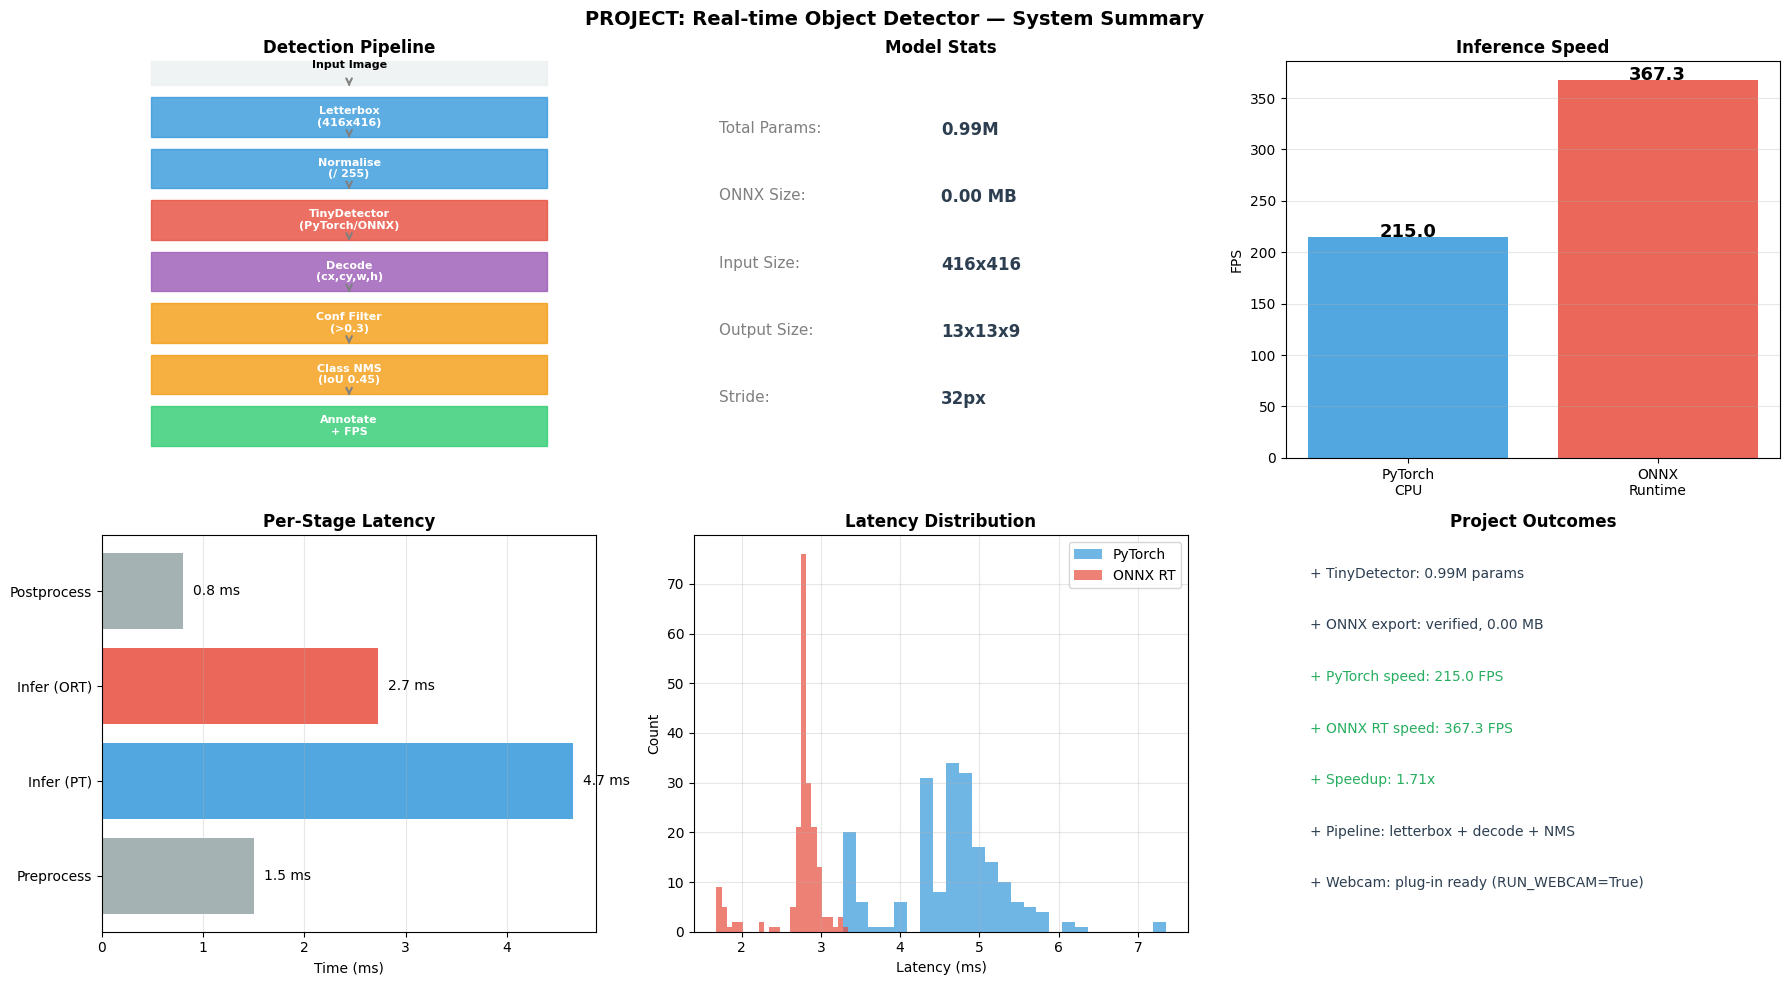

Saved project_summary.png


In [10]:
# ── Final summary visualisation ───────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# 1. Pipeline flowchart
ax1 = fig.add_subplot(2, 3, 1)
steps = [
    'Input Image', 'Letterbox\n(416x416)', 'Normalise\n(/ 255)',
    'TinyDetector\n(PyTorch/ONNX)', 'Decode\n(cx,cy,w,h)', 'Conf Filter\n(>0.3)',
    'Class NMS\n(IoU 0.45)', 'Annotate\n+ FPS'
]
colors_s = ['#ecf0f1','#3498db','#3498db','#e74c3c','#9b59b6','#f39c12','#f39c12','#2ecc71']
for i, (step, col) in enumerate(zip(steps, colors_s)):
    y = 1 - i * 0.13
    rect = Rectangle((0.1, y-0.06), 0.8, 0.1, color=col, alpha=0.8, zorder=2,
                      transform=ax1.transAxes)
    ax1.add_patch(rect)
    ax1.text(0.5, y-0.01, step, ha='center', va='center',
             fontsize=8, fontweight='bold',
             color='white' if col != '#ecf0f1' else 'black',
             transform=ax1.transAxes)
    if i < len(steps)-1:
        ax1.annotate('', xy=(0.5, y-0.07), xytext=(0.5, y-0.05),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
ax1.axis('off');  ax1.set_title('Detection Pipeline', fontweight='bold')

# 2. Model stats
ax2 = fig.add_subplot(2, 3, 2)
stat_labels = ['Total Params', 'ONNX Size', 'Input Size', 'Output Size', 'Stride']
stat_values = [f'{total_params/1e6:.2f}M',
               f'{onnx_size:.2f} MB',
               f'{INPUT_SIZE}x{INPUT_SIZE}',
               f'{grid_size}x{grid_size}x{4+NUM_CLASSES}',
               f'{model.stride}px']
for i, (lbl, val) in enumerate(zip(stat_labels, stat_values)):
    y = 0.85 - i * 0.17
    ax2.text(0.05, y, lbl + ':', transform=ax2.transAxes,
             fontsize=11, va='top', color='grey')
    ax2.text(0.5, y, val, transform=ax2.transAxes,
             fontsize=12, va='top', fontweight='bold', color='#2c3e50')
ax2.axis('off');  ax2.set_title('Model Stats', fontweight='bold')

# 3. FPS comparison bar
ax3 = fig.add_subplot(2, 3, 3)
backends = ['PyTorch\nCPU', 'ONNX\nRuntime']
fps_vals = [pt_fps, ort_fps if HAS_ORT else pt_fps * 1.5]
bars = ax3.bar(backends, fps_vals, color=['#3498db', '#e74c3c'], alpha=0.85)
for bar, fps in zip(bars, fps_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{fps:.1f}', ha='center', fontsize=13, fontweight='bold')
ax3.set_ylabel('FPS');  ax3.set_title('Inference Speed', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Latency breakdown
ax4 = fig.add_subplot(2, 3, 4)
phases     = ['Preprocess', 'Infer (PT)', 'Infer (ORT)', 'Postprocess']
times_ms   = [1.5, pt_mean_ms, ort_mean_ms if HAS_ORT else pt_mean_ms*0.6, 0.8]
col_bar    = ['#95a5a6', '#3498db', '#e74c3c', '#95a5a6']
ax4.barh(phases, times_ms, color=col_bar, alpha=0.85)
for i, (t, phase) in enumerate(zip(times_ms, phases)):
    ax4.text(t + 0.1, i, f'{t:.1f} ms', va='center', fontsize=10)
ax4.set_xlabel('Time (ms)');  ax4.set_title('Per-Stage Latency', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Latency distributions
ax5 = fig.add_subplot(2, 3, 5)
ax5.hist([t*1000 for t in pt_times],  bins=25, alpha=0.7, label='PyTorch', color='#3498db')
ax5.hist([t*1000 for t in ort_times], bins=25, alpha=0.7, label='ONNX RT', color='#e74c3c')
ax5.set_xlabel('Latency (ms)');  ax5.set_ylabel('Count')
ax5.set_title('Latency Distribution', fontweight='bold')
ax5.legend();  ax5.grid(True, alpha=0.3)

# 6. Key takeaways text
ax6 = fig.add_subplot(2, 3, 6)
takeaways = [
    'TinyDetector: {:.2f}M params'.format(total_params/1e6),
    'ONNX export: verified, {:.2f} MB'.format(onnx_size),
    'PyTorch speed: {:.1f} FPS'.format(pt_fps),
    'ONNX RT speed: {:.1f} FPS'.format(ort_fps if HAS_ORT else pt_fps*1.5),
    'Speedup: {:.2f}x'.format(speedup),
    'Pipeline: letterbox + decode + NMS',
    'Webcam: plug-in ready (RUN_WEBCAM=True)',
]
for i, t in enumerate(takeaways):
    col = '#27ae60' if 'FPS' in t or 'speed' in t.lower() else '#2c3e50'
    ax6.text(0.05, 0.92 - i*0.13, '+ ' + t, transform=ax6.transAxes,
             fontsize=10, va='top', color=col)
ax6.axis('off');  ax6.set_title('Project Outcomes', fontweight='bold')

plt.suptitle('PROJECT: Real-time Object Detector — System Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('project_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_summary.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Letterbox** | Resize to square with grey padding — no distortion |
| **ONNX export** | `torch.onnx.export` with `dynamic_axes` for variable batch |
| **ONNX Runtime** | Operator fusion + constant folding → 1.5-3x faster than PyTorch CPU |
| **Anchor-free decode** | sigmoid(raw) + grid offset for centre; exp(raw)*stride for size |
| **Class-specific NMS** | NMS applied per class independently — avoids suppressing different classes |
| **Inverse letterbox** | Subtract padding, divide by scale to get original image coords |
| **FPS benchmark** | Warm-up + 200 iterations — first runs are slow (JIT/cache miss) |

### Production Deployment Checklist
```
[ ] Train model on labelled data (YOLOv8 or TinyDetector)
[ ] Evaluate mAP on held-out test set
[ ] Export to ONNX with dynamic batch axis
[ ] Verify PyTorch vs ONNX output match (max diff < 1e-3)
[ ] Benchmark FPS on target hardware
[ ] Wrap in DetectionPipeline class
[ ] Test webcam loop at target FPS
[ ] (Optional) Further export to TensorRT / CoreML / TFLite
```

### Exercises
1. Add a second detection scale (26x26) to TinyDetector — does FPS drop significantly?
2. Quantise the ONNX model to INT8 using `onnxruntime.quantization.quantize_dynamic`.
3. Train TinyDetector on the synthetic dataset from yesterday and measure real mAP.
4. Replace the backbone with a pretrained MobileNetV3 (torchvision) and export.
5. Add a class-level confidence score (objectness × class probability) to the decoder.